### **가설 검증 2: 사고나 이용량 변화가 '코로나' 때문인지 확인(통제 변수 분석)**

#### PM 사고 건수의 증가 요인 중 하나가 코로나19 팬데믹으로 인한 개인 이동수단 선호 현상 때문일 가능성이 있는지 확인합니다.
#### 코로나 확진자 수와 PM 사고 건수의 상관관계를 분석하여 이 요인을 통제할 수 있는지 살펴봅니다.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

In [34]:
# 시각화 시 한글 폰트 깨짐 방지 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

****

#### **데이터 불러오기**
##### 가설 검증에 필요한 데이터를 불러옵니다.

In [35]:
# 코로나 데이터 불러오기
df_covid = pd.read_csv("서울시 자치구별 코로나 확진자 현황(월별)\서울시_자치구별_월별_코로나19_확진자수.csv", 
                       encoding='utf-8')
df_covid_monthly = df_covid.groupby('연월')['월별_확진자수'].sum().reset_index()

# PM 교통사고 데이터 불러오기
df_acc = pd.read_csv('서울시 PM 교통사고 현황\서울시_자치구별_월별_PM교통사고.csv',
                     encoding='utf-8')
df_acc_monthly_total = df_acc.groupby('연월')['PM_사고건수'].sum().reset_index()

print('코로나 데이터 크기: ', df_covid_monthly.shape)
display(df_covid_monthly.head())
print('월별 전체 PM 사고 건수 크기: ', df_acc_monthly_total.shape)
display(df_acc_monthly_total.head())

코로나 데이터 크기:  (44, 2)


,연월,월별_확진자수
0,2020-01,7
1,2020-02,66
2,2020-03,370
3,2020-04,146
4,2020-05,216


월별 전체 PM 사고 건수 크기:  (72, 2)


,연월,PM_사고건수
0,2019-01,8
1,2019-02,5
2,2019-03,4
3,2019-04,7
4,2019-05,24


****

#### **데이터 병합(Merge)**
##### 코로나 데이터와 월별 전체 PM 사고 건수를 `df_merge_covid`로 병합합니다.

In [36]:
# 데이터 병합
df_merge_covid = pd.merge(df_acc_monthly_total, df_covid_monthly, on='연월', how='inner')
display(df_merge_covid.head())

,연월,PM_사고건수,월별_확진자수
0,2020-01,19,7
1,2020-02,31,66
2,2020-03,17,370
3,2020-04,36,146
4,2020-05,50,216


****

#### **계절성 통제: 전년 동월 대비(YoY) 분석**
##### PM 특성상 계절성 요인을 고려하지 않고 분석하면, 노이즈가 발생하여 분석 결과의 신뢰도가 떨어질 수 있습니다.
##### 계절성을 통제하여 분석함으로써, 더 나은 품질의 결과를 도출합니다.

In [37]:
# 계절성 통제:  전년 동월 대비(YoY) 분석
# '연월'을 datetime 타입으로 변환 후 시간순으로 정렬 (시계열 연산)
df_merge_covid['연월_dt'] = pd.to_datetime(df_merge_covid['연월'])
df_merge_covid = df_merge_covid.sort_values('연월_dt').reset_index(drop=True)

# periods=12를 사용하여 정확히 12개월(1년) 전의 데이터와 차이(증감)를 계산
# => "계절성"이 동일한 시점끼리 비교하게 됨
df_merge_covid['PM_사고건수_YoY_diff'] = df_merge_covid['PM_사고건수'].diff(periods=12)
df_merge_covid['월별_확진자수_YoY_diff'] = df_merge_covid['월별_확진자수'].diff(periods=12)

# 첫 1년(12개월)의 데이터는 비교할 과거 데이터가 없으므로 결측치(NaN)가 발생 -> 이를 제거
df_yoy = df_merge_covid.dropna(subset=['PM_사고건수_YoY_diff', '월별_확진자수_YoY_diff'])

print("=== 계절성을 통제한 전년 동월 대비 데이터 (상위 5개) ===")
display(df_yoy[['연월', 'PM_사고건수_YoY_diff', '월별_확진자수_YoY_diff']].head())

=== 계절성을 통제한 전년 동월 대비 데이터 (상위 5개) ===


,연월,PM_사고건수_YoY_diff,월별_확진자수_YoY_diff
12,2021-01,9.0,4274.0
13,2021-02,5.0,3583.0
14,2021-03,30.0,3288.0
15,2021-04,34.0,5338.0
16,2021-05,12.0,5564.0


#### **상관관계 분석 및 시각화**

In [38]:
# 전년 동월 대비 변화량으로 Pearson 상관관계 분석
corr_yoy, p_yoy = pearsonr(df_yoy['월별_확진자수_YoY_diff'], df_yoy['PM_사고건수_YoY_diff'])

print("\n=== 전년 동월 대비 코로나 확진자 증감과 PM 사고 증감 상관관계 ===")
print(f"상관계수(r): {corr_yoy:.4f}")
print(f"p-value: {p_yoy:.4f}")

if p_yoy < 0.05:
    print("결론: 통계적으로 유의미한 상관관계가 있습니다.")
else:
    print("결론: 코로나 확진자 수 변화와 PM 사고 건수 변화 간에는 유의미한 상관관계가 발견되지 않았습니다.")


=== 전년 동월 대비 코로나 확진자 증감과 PM 사고 증감 상관관계 ===
상관계수(r): -0.2976
p-value: 0.0981
결론: 코로나 확진자 수 변화와 PM 사고 건수 변화 간에는 유의미한 상관관계가 발견되지 않았습니다.


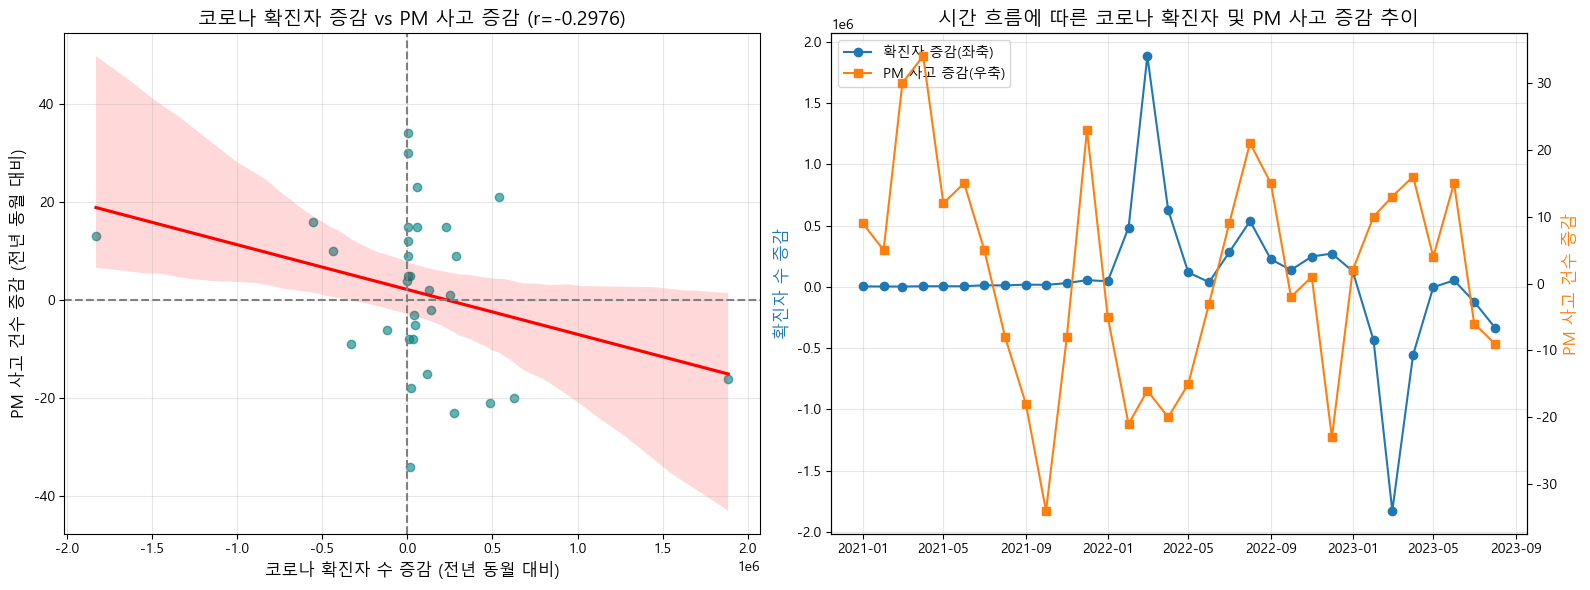

In [46]:
# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽 그래프: 기존 산점도 유지
sns.regplot(data=df_yoy, x='월별_확진자수_YoY_diff', y='PM_사고건수_YoY_diff', 
            scatter_kws={'alpha':0.6, 'color':'teal'}, line_kws={'color':'red'}, ax=ax1)
ax1.set_title(f'코로나 확진자 증감 vs PM 사고 증감 (r={corr_yoy:.4f})', fontsize=14)
ax1.set_xlabel('코로나 확진자 수 증감 (전년 동월 대비)', fontsize=12)
ax1.set_ylabel('PM 사고 건수 증감 (전년 동월 대비)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='grey', linestyle='--') 
ax1.axvline(0, color='grey', linestyle='--') 

# 오른쪽 그래프: 시간 흐름에 따른 듀얼 축 라인 플롯 (새로 추가)
ax2_twin = ax2.twinx() # 두 번째 y축 생성

# 확진자 증감 라인 (파란색)
line1 = ax2.plot(df_yoy['연월_dt'], df_yoy['월별_확진자수_YoY_diff'], 
                 color='#1f77b4', marker='o', label='확진자 증감(좌축)')
# 사고 건수 증감 라인 (주황색)
line2 = ax2_twin.plot(df_yoy['연월_dt'], df_yoy['PM_사고건수_YoY_diff'], 
                      color='#ff7f0e', marker='s', label='PM 사고 증감(우축)')

ax2.set_title('시간 흐름에 따른 코로나 확진자 및 PM 사고 증감 추이', fontsize=14)
ax2.set_ylabel('확진자 수 증감', color='#1f77b4', fontsize=12)
ax2_twin.set_ylabel('PM 사고 건수 증감', color='#ff7f0e', fontsize=12)
ax2.grid(True, alpha=0.3)

# 범례 합치기
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

- **코로나 확진자 증감 vs PM 사고 증감 (r=-0.2976)**
  - 상관계수(r)가 -0.2976, p-value가 0.0981로 도출되었습니다.
  - 이는 코로나 확진자 수의 증감과 PM 사고 발생 건수 사이에는 통계적으로 유의미한 상관관계가 없음을 의미합니다.
  
- **시간 흐름에 따른 코로나 확진자 및 PM 사고 증감 추이**
  - 파란색 선(확진자 수 증감)을 보면 2022년 초중순(오미크론 대유행 시기)에 하늘을 뚫을 듯이 폭증합니다. 그런데 바로 그 시점, 주황색 선(PM 사고 건수 증감)은 오히려 0선 아래(마이너스)로 곤두박질치고 있습니다. 반대로 주황색 선이 가장 높게 치솟았던 2021년 하반기에는 파란색 선이 바닥에 머물러 있습니다.

****

#### **사회적 거리두기 단계와 PM 사고 건수의 상관관계 분석**
거리두기 단계를 수치화(0~4단계)하고, '강화기, 완화기, 미시행/해제'의 3그룹으로 분류하여 분석을 진행합니다.

사용 연혁 데이터: `질병관리청_사회적 거리두기 시행연혁_20220901.hwpx`

In [40]:
# 서울/수도권 기준 공식 거리두기 연혁 (2020.01 ~ 2022.12)
# 월 중순에 단계가 바뀐 경우, 해당 월의 PM 이용에 타격을 준 '최고 단계' 또는 '가장 오래 유지된 단계'를 기준으로 보정했습니다.
distancing_history_seoul = {
    '연월': [
        '2020-01', '2020-02', '2020-03', '2020-04', '2020-05', '2020-06', 
        '2020-07', '2020-08', '2020-09', '2020-10', '2020-11', '2020-12',
        '2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06', 
        '2021-07', '2021-08', '2021-09', '2021-10', '2021-11', '2021-12',
        '2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06',
        '2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12'
    ],
    '거리두기_단계': [
        0, 0, 2, 1.5, 1, 1,        # 2020 상반기 (3월: 강화된, 4월: 완화된, 5월: 생활속)
        1, 2.5, 2.5, 1, 2, 2.5,    # 2020 하반기 (8월 말~9월 초 2.5단계, 12월 2.5단계)
        2.5, 2, 2, 2, 2, 2,        # 2021 상반기 (1월 2.5단계, 2월 중순부터 2단계 하향 유지)
        4, 4, 4, 4, 0, 4,          # 2021 하반기 (7월부터 신규 4단계, 11월 위드코로나, 12월 중순 규제 재강화)
        4, 4, 3, 0, 0, 0,          # 2022 상반기 (4.18 전면해제 전까지 규제 지속, 3월 일부 완화 반영)
        0, 0, 0, 0, 0, 0           # 2022 하반기 (해제 유지)
    ]
}

# 데이터프레임으로 변환
df_dist_seoul = pd.DataFrame(distancing_history_seoul)

21년 11월과 12월은 공식적인 '단계명'이 폐지되었으나, 11월은 '단계적 일상회복'으로 야외 활동이 자유로웠으므로 0단계로 수치화하고, 12월은 '거리두기 강화' 조치로 인해 21시 영업제한 등 사실상 4단계 수준의 강력한 제한이 가해졌으므로 4단계로 스케일링(Scaling)하여 분석합니다.

In [41]:
# 기존 PM 사고 및 확진자 데이터프레임(df_merge_covid)에 병합
df_final = pd.merge(df_merge_covid, df_dist_seoul, on='연월', how='inner')

# 범주형 그룹화 로직 (T-test / ANOVA 분석용)
# 기준: 2.5단계 이상(사실상 야간활동 통제) = 강화기 / 1~2단계 = 완화기 / 0단계 = 해제
def categorize_distancing(level):
    if level >= 2.5:
        return '강화기'
    elif level > 0:
        return '완화기'
    else:
        return '미시행/해제'

df_final['거리두기_그룹'] = df_final['거리두기_단계'].apply(categorize_distancing)

# 최종 확인
print("=== 서울시 거리두기 파생 변수 병합 완료 ===")
display(df_final[['연월', 'PM_사고건수', '월별_확진자수', '거리두기_단계', '거리두기_그룹']].head(10))

=== 서울시 거리두기 파생 변수 병합 완료 ===


,연월,PM_사고건수,월별_확진자수,거리두기_단계,거리두기_그룹
0,2020-01,19,7,0.0,미시행/해제
1,2020-02,31,66,0.0,미시행/해제
2,2020-03,17,370,2.0,완화기
3,2020-04,36,146,1.5,완화기
4,2020-05,50,216,1.0,완화기
5,2020-06,49,434,1.0,완화기
6,2020-07,68,269,1.0,완화기
7,2020-08,61,2190,2.5,강화기
8,2020-09,70,1229,2.5,강화기
9,2020-10,93,651,1.0,완화기


In [42]:
# 필요한 통계 라이브러리 추가 로드
from scipy.stats import f_oneway

이전과 마찬가지로 전년 동월 대비 방식으로 분석을 진행합니다.

In [43]:
# 12개월(1년) 전의 데이터와 차이(증감)를 계산하여 계절성을 통제
df_final['PM_사고건수_YoY_diff'] = df_final['PM_사고건수'].diff(periods=12)
df_final['거리두기_단계_YoY_diff'] = df_final['거리두기_단계'].diff(periods=12)

# 최초 12개월의 결측치(NaN) 데이터 제거
df_dist_yoy = df_final.dropna(subset=['PM_사고건수_YoY_diff', '거리두기_단계_YoY_diff'])

print("=== 계절성을 통제한 거리두기 데이터 (상위 5개) ===")
display(df_dist_yoy[['연월', '거리두기_단계', '거리두기_그룹', 'PM_사고건수_YoY_diff']].head())

=== 계절성을 통제한 거리두기 데이터 (상위 5개) ===


,연월,거리두기_단계,거리두기_그룹,PM_사고건수_YoY_diff
12,2021-01,2.5,강화기,9.0
13,2021-02,2.0,완화기,5.0
14,2021-03,2.0,완화기,30.0
15,2021-04,2.0,완화기,34.0
16,2021-05,2.0,완화기,12.0


- **피어슨 상관계수(`pearsonr()`)**
  * **두 개의 연속된 수치형 데이터 사이**에 선형적인 비례(또는 반비례) 관계가 있는지 확인하기 위해 사용합니다. 한쪽이 증가할 때 다른 쪽도 일정한 비율로 증가하거나 감소하는지 확인합니다.
  * '거리두기 단계 증감분(숫자)'과 'PM 사고 건수 증감분(숫자)'이 1:1로 같이 움직이는지 확인합니다.

- **일원배치 분산분석, ANOVA(`f_oneway()`)**
  * **세 개 이상의 독립적인 그룹(범주형 데이터) 간**에 평균값의 차이가 통계적으로 진짜 의미가 있는지(우연이 아닌지) 검증할 때 사용합니다.
  * '미시행/해제', '완화기', '강화기'라는 3개의 카테고리(그룹) 각각의 평균 사고 증감량에 실제로 뚜렷한 차이가 있는지 확인합니다.

+ **두 그룹을 비교**할 때는 주로 T-test를 씁니다.

In [44]:
# [수치형 분석] 거리두기 단계 증감분과 PM 사고 건수 증감분의 Pearson 상관관계
corr_dist_yoy, p_dist_yoy = pearsonr(df_dist_yoy['거리두기_단계_YoY_diff'], df_dist_yoy['PM_사고건수_YoY_diff'])
print(f"\n[참고] 거리두기 단계 증감(YoY)과 PM 사고 건수 증감(YoY) 상관계수(r): {corr_dist_yoy:.4f} (p-value: {p_dist_yoy:.4f})")

# [범주형 분석] 각 거리두기 그룹별 전년 동월 대비 증감분 분리
group_free_yoy = df_dist_yoy[df_dist_yoy['거리두기_그룹'] == '미시행/해제']['PM_사고건수_YoY_diff']
group_mild_yoy = df_dist_yoy[df_dist_yoy['거리두기_그룹'] == '완화기']['PM_사고건수_YoY_diff']
group_hard_yoy = df_dist_yoy[df_dist_yoy['거리두기_그룹'] == '강화기']['PM_사고건수_YoY_diff']

print("\n=== 거리두기 그룹별 PM 사고 건수 증감(YoY) 기초 통계 ===")
print(f"1. 미시행/해제 (증감 평균): {group_free_yoy.mean():.2f}건")
print(f"2. 완화기      (증감 평균): {group_mild_yoy.mean():.2f}건")
print(f"3. 강화기      (증감 평균): {group_hard_yoy.mean():.2f}건\n")

# 일원배치 분산분석 (One-way ANOVA)
f_stat_yoy, p_anova_yoy = f_oneway(group_free_yoy, group_mild_yoy, group_hard_yoy)
print("=== 일원배치 분산분석 (One-way ANOVA) [계절성 통제] ===")
print(f"F-statistic: {f_stat_yoy:.4f}")
print(f"p-value: {p_anova_yoy:.4f}")

if p_anova_yoy < 0.05:
    print("결론: 계절성을 통제했을 때, 세 거리두기 그룹 간에 PM 사고 증감량의 평균은 통계적으로 유의미한 차이가 있습니다.\n")
else:
    print("결론: 계절성을 통제했을 때, 세 거리두기 그룹 간에 PM 사고 증감량의 평균은 통계적으로 유의미한 차이가 없습니다.\n")


[참고] 거리두기 단계 증감(YoY)과 PM 사고 건수 증감(YoY) 상관계수(r): -0.0664 (p-value: 0.7579)

=== 거리두기 그룹별 PM 사고 건수 증감(YoY) 기초 통계 ===
1. 미시행/해제 (증감 평균): -2.50건
2. 완화기      (증감 평균): 19.20건
3. 강화기      (증감 평균): -7.22건

=== 일원배치 분산분석 (One-way ANOVA) [계절성 통제] ===
F-statistic: 5.0301
p-value: 0.0164
결론: 계절성을 통제했을 때, 세 거리두기 그룹 간에 PM 사고 증감량의 평균은 통계적으로 유의미한 차이가 있습니다.



1. 거리두기 단계 수치와 사고 증감량 사이에 선형적인 상관관계는 없다고 나왔습니다.
  "거리두기 단계가 1->2->3->4로 올라갈수록 사고도 똑같이 비례해서 줄어들거나 늘어난다"는 식의 단순한 1차원적 관계가 아니라는 뜻입니다.

2. **완화기 (평균 +19.20건 증가):** 작년 같은 달과 비교했을 때 PM 사고가 눈에 띄게 증가했습니다.


1. **강화기 (평균 -7.22건 감소) / 미시행 (평균 -2.50건 감소):** 이 시기에는 전년 동월 대비 PM 사고가 오히려 줄어들거나 비슷한 수준을 유지했습니다.

1. **ANOVA 유의미한 차이 발견:**
  p-value가 0.0164로 기준치인 0.05보다 작게 도출되었습니다. 이는 계절적 요인(날씨, 계절)을 걷어내고 순수하게 증감량만 비교했을 때, 사회적 거리두기 단계(미시행/완화기/강화기)에 따라 PM 사고 발생 규모가 통계적으로 확실한 차이를 보인다는 것을 의미합니다.

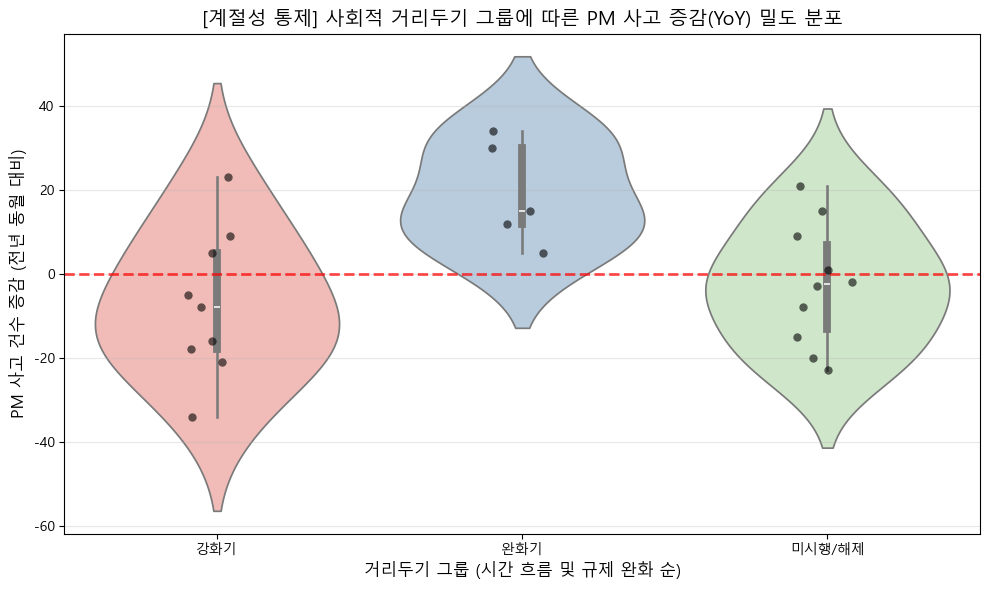

In [48]:
# 시각화 (Violinplot)
plt.figure(figsize=(10, 6))
order_list = ['강화기', '완화기', '미시행/해제'] 

# Boxplot 대신 Violinplot 사용
sns.violinplot(data=df_dist_yoy, x='거리두기_그룹', y='PM_사고건수_YoY_diff', 
               order=order_list, palette='Pastel1')

# Stripplot 겹쳐 그리기
sns.stripplot(data=df_dist_yoy, x='거리두기_그룹', y='PM_사고건수_YoY_diff', 
              order=order_list, color='black', alpha=0.6, jitter=True, size=6)

plt.title('[계절성 통제] 사회적 거리두기 그룹에 따른 PM 사고 증감(YoY) 밀도 분포', fontsize=14)
plt.xlabel('거리두기 그룹 (시간 흐름 및 규제 완화 순)', fontsize=12) # 축 설명 보강
plt.ylabel('PM 사고 건수 증감 (전년 동월 대비)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.axhline(0, color='red', linestyle='--', alpha=0.7, linewidth=2) 

plt.tight_layout()
plt.show()

- **사회적 거리두기 그룹에 따른 PM 사고 건수 증감(YoY) 분포**
  - 맨 왼쪽의 '미시행/해제' 바이올린을 보면 데이터가 0점 근처에서 아주 안정적으로 뭉쳐 있고, 오히려 살짝 감소세를 띠고 있습니다.

  - 세 개의 바이올린 중 오직 '완화기' 데이터만 두터운 몸통과 내부의 중앙값(하얀 점)이 붉은색 0선 위쪽(+ 구간)에 확연하게 붕 떠 있습니다. 반면 강화기와 미시행/해제 시기는 0선 이하(- 구간)에 머물러 있습니다.
  

- **확진자 수가 아닌 '방역 정책의 강도(거리두기 단계)'가 대중의 이동 패턴을 결정했음을 알 수 있습니다.**


- **거리두기가 완전히 해제되고 코로나가 일상화(엔데믹)되면서, PM에 쏠렸던 비정상적인 수요가 다시 대중교통으로 분산되면서, PM 사고 증가율도 예년 수준으로 안정화되었음을 보여줍니다.**

****

****

* **왜 '완화기'에만 유독 사고가 급증했는가?**
  
  강력한 통제(강화기)로 인해 억눌려 있던 이동 수요가 완화기에 폭발적으로 증가했을 가능성이 큽니다. 이때, 외부 활동은 늘어났지만 여전히 코로나 감염 우려로 인해 밀집된 대중교통(버스, 지하철)보다는 혼자 탈 수 있는 '개인형 이동장치(PM)'를 대체 수단으로 강하게 선호하면서 사고가 급증한 것으로 해석해 볼 수 있습니다.

* **강화기와 미시행/해제 시기에는 사고 건수가 왜 안정화되었는가?**
  
  강화기에는 야간 영업 제한 등으로 사람들의 절대적인 이동량 자체가 줄어들어 사고가 감소했습니다. 반면 거리두기가 완전히 해제된 시기에는 코로나에 대한 경각심이 줄어들며 대중교통 이용이 다시 정상화되었고, 그로 인해 비정상적으로 높았던 PM 수요도 안정세(또는 감소세)로 접어든 것으로 추론할 수 있습니다.

### **소결론**
- 코로나19 확진자 수의 절대적인 증감은 PM 사고 발생 건수와 통계적으로 무관했습니다.
- PM 사고를 폭증시킨 실질적인 원인 중 하나는 '사회적 거리두기 완화기'라는 특수한 외부 요인으로 추론할 수 있습니다. 즉, 코로나 팬데믹 기간(2020~2022년)의 PM 사고 급증은 일시적인 외부 통제 변수(팬데믹 심리)가 강력하게 작용한 결과로 해석해야 합니다.